In [1]:
import sys
import os

# Add the project root to the sys.path so we can import 'core'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import librosa
import numpy as np
import pandas as pd
from core.stt.stt_pipeline import STTEngine

# 1. Initialize the Engine (loads weights into VRAM)
print("Initializing STT Engine...")
engine = STTEngine(asr_model_size="base", device="cuda", compute_type="float16")

# 2. Create a fresh streaming session
session = engine.create_session()

Initializing STT Engine...


In [2]:
# --- Configuration ---
TEST_AUDIO_PATH = "/media/edwardl.campbell/D/Data-io/sps-corpus-1.0-2025-11-25-en/audios/spontaneous-speech-en-67856.mp3"
NETWORK_CHUNK_SIZE = 2048  # Simulating ~128ms network payloads

print(f"Loading and resampling: {TEST_AUDIO_PATH}")
# Ensure 16kHz mono for Silero/Whisper
audio_data, _ = librosa.load(TEST_AUDIO_PATH, sr=16000, mono=True)

# Convert the float32 numpy array into raw bytes (simulating WebSocket binary transfer)
raw_audio_bytes = audio_data.astype(np.float32).tobytes()

results = []
bytes_per_chunk = NETWORK_CHUNK_SIZE * 4 # 4 bytes per float32

print("Simulating WebSocket stream...")

# Feed the bytes into the session chunk by chunk
for i in range(0, len(raw_audio_bytes), bytes_per_chunk):
    byte_chunk = raw_audio_bytes[i : i + bytes_per_chunk]

    # This is the exact function your FastAPI server calls
    record = session.process_chunk(byte_chunk)

    if record and record["type"] == "transcript":
        results.append(record)
        print(f"Captured: {record['text']}")

# Flush the remaining buffer at EOF (simulating connection close)
# In a real stream, you might want to expose a manual `session.flush()` method
# to force a transcription of the residual buffer if the user hangs up abruptly.

Loading and resampling: /media/edwardl.campbell/D/Data-io/sps-corpus-1.0-2025-11-25-en/audios/spontaneous-speech-en-67856.mp3
Simulating WebSocket stream...
Captured: I  remember  quite  a  lot  of  my  childhood.  It  was  a  very  varied  childhood.  I  was  born  in  Uganda.
Captured: And  I  don't  really  remember  that  much  of  Africa  except  a  couple  of  visuals,  a  couple  of...
Captured: pictures  in  my  mind  and  when  I  went  back  to  Uganda  at  the  age  of  60,  I  did  actually  see  something  that  I  must  have  last  seen  when  I  was  about  two  years  old.  It  was  the  church  with  that  I  was  at  the  end  of  the  road  where...
Captured: my  parents  lived.  I  remember  we  moved  to  Fiji  and  I  remember  that  much  better.  I  was  about  four  or  five  and  I  particularly  have  some  memories  of  the  lovely  lady  who  was  looking  after  me  and  my  younger  sister  who  was  a  baby  walking  on  very  sharp  stones  in  bare  fe

In [3]:
# Flatten the records for Pandas
flat_data = []
for r in results:
    # This automatically strips double spaces and NBSP characters
    clean_text = " ".join(r["text"].split())

    flat_data.append({
        "Transcript": clean_text,
        "Duration (s)": r["metrics"]["audio_duration_s"],
        "Inference (ms)": r["metrics"]["inference_time_ms"],
        "RTF": r["metrics"]["rtf"],
        "End-Point Latency (ms)": r["metrics"]["endpoint_latency_ms"]
    })

df_metrics = pd.DataFrame(flat_data)

print("\n--- Pipeline Performance Summary ---")
display(df_metrics)

# Optional: Print aggregate statistics
print(f"\nAverage End-Point Latency: {df_metrics['End-Point Latency (ms)'].mean():.0f} ms")
print(f"Average RTF: {df_metrics['RTF'].mean():.4f}")


--- Pipeline Performance Summary ---


,Transcript,Duration (s),Inference (ms),RTF,End-Point Latency (ms)
0,I remember quite a lot of my childhood. It was...,6.88,9.0,0.0013,1129.0
1,And I don't really remember that much of Afric...,8.77,8.0,0.0009,776.0
2,pictures in my mind and when I went back to Ug...,16.03,11.0,0.0007,1063.0
3,my parents lived. I remember we moved to Fiji ...,46.30,24.0,0.0005,1148.0
4,and so many memories of that. I remember a sto...,5.06,4.0,0.0007,1040.0
5,everybody else was being sick and I was about ...,90.56,46.0,0.0005,1306.0
6,primary school I went to was...,3.74,3.0,0.0008,1747.0
7,"I have a vivid memory, although, again, quite ...",10.66,6.0,0.0005,662.0
8,pain of having the ruler on my hand because I ...,66.75,46.0,0.0007,78.0
9,My younger sister was quite difficult for me b...,14.85,8.0,0.0005,976.0



Average End-Point Latency: 1025 ms
Average RTF: 0.0008


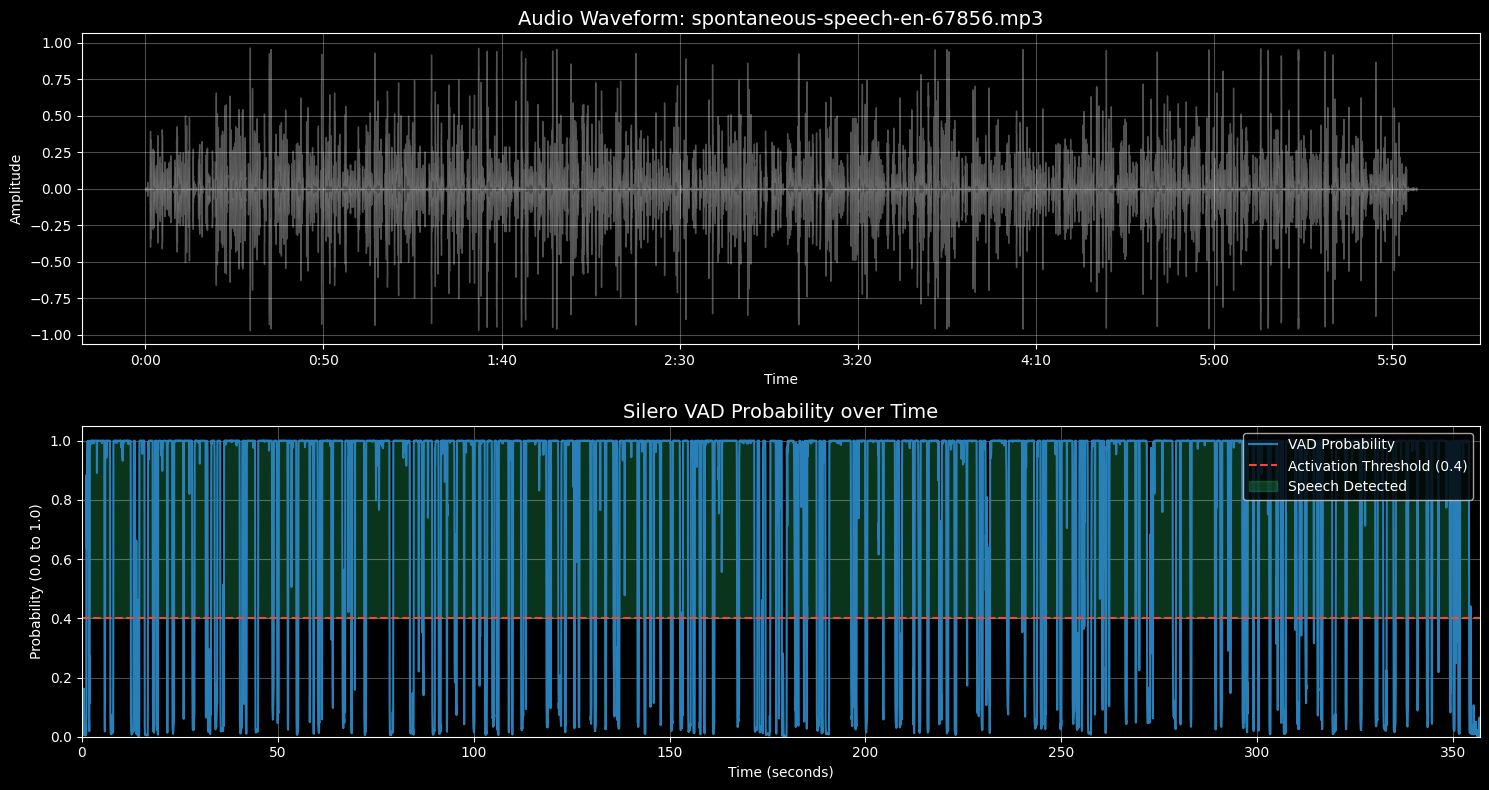

In [4]:
import matplotlib.pyplot as plt
import librosa.display
import torch
import numpy as np

# 1. Setup
vad_model = engine.vad_model
vad_model.reset_states() # Always reset before processing a new file
window_size = 512
sample_rate = 16000
vad_threshold = 0.4      # The threshold we want to visualize

audio, _ = librosa.load(TEST_AUDIO_PATH, sr=sample_rate, mono=True)

vad_probs = []
time_stamps = []

# 2. Extract VAD probabilities chunk-by-chunk
for i in range(0, len(audio), window_size):
    chunk = audio[i:i+window_size]

    # Pad the final chunk if it's too short
    if len(chunk) < window_size:
        chunk = np.pad(chunk, (0, window_size - len(chunk)))

    tensor_chunk = torch.from_numpy(chunk).float()

    with torch.no_grad():
        prob = vad_model(tensor_chunk, sample_rate).item()

    vad_probs.append(prob)
    # Record the time at the *start* of the chunk
    time_stamps.append(i / sample_rate)

# 3. Visualization
plt.figure(figsize=(15, 8))

# --- Top Plot: Raw Audio Waveform ---
plt.subplot(2, 1, 1)
librosa.display.waveshow(audio, sr=sample_rate, alpha=0.6, color='gray')
plt.title(f'Audio Waveform: {TEST_AUDIO_PATH.split("/")[-1]}', fontsize=14)
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# --- Bottom Plot: Silero VAD Probabilities ---
plt.subplot(2, 1, 2)
plt.plot(time_stamps, vad_probs, label='VAD Probability', color='#2980b9', linewidth=1.5)

# Draw the VAD activation threshold
plt.axhline(y=vad_threshold, color='#e74c3c', linestyle='--', label=f'Activation Threshold ({vad_threshold})')

# Highlight regions where the VAD considers the user to be speaking
plt.fill_between(
    time_stamps,
    vad_probs,
    vad_threshold,
    where=(np.array(vad_probs) > vad_threshold),
    alpha=0.3,
    color='#27ae60',
    label='Speech Detected'
)

plt.title('Silero VAD Probability over Time', fontsize=14)
plt.xlabel('Time (seconds)')
plt.ylabel('Probability (0.0 to 1.0)')
plt.ylim(0, 1.05)
plt.xlim(0, len(audio) / sample_rate)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
from core.stt.agent import create_agent
from langchain_core.messages import SystemMessage, HumanMessage

# Initialize the agent
agent_app = create_agent(
    model_name="Qwen/Qwen2.5-3B-Instruct-AWQ",
    api_base="http://localhost:8000/v1",
    temperature=0.2
)

print("Agent Initialized.")

# Configuration for thread tracking
config = {"configurable": {"thread_id": "test_session_1"}}

# Define the initial system prompt
system_prompt = SystemMessage(
    content="You are Marie, an AI assistant for the legal sector. Provide brief, precise answers."
)
agent_app.invoke({"messages": [system_prompt]}, config=config)

print("Testing the agent with the transcript outputs from the STT stream...")

# Process each captured transcript with the agent
for r in results:
    clean_text = " ".join(r["text"].split())
    if not clean_text:
        continue

    print(f"\nUser (ASR Output): {clean_text}")
    print("Marie: ", end="", flush=True)

    new_message = {"messages": [HumanMessage(content=clean_text)]}

    for event in agent_app.stream(new_message, config=config, stream_mode="messages"):
        if event[0].content:
            print(event[0].content, end="", flush=True)

    print() # Newline after response completes


Agent Initialized.


APIConnectionError: Connection error.